# M5: Fusion

## Imports & Config

In [1]:
import os, random
import numpy as np
import tensorflow as tf
from keras.layers import Input, Dense, Dropout, Concatenate, BatchNormalization
from keras.models import Model, load_model
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE= 0.0001
DROPOUT_RATE = 0.3

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'


## Load Data

In [2]:
X_img = np.load(os.path.join(PROCESSED_DIR, 'X_img.npy'), mmap_mode='r')
X_text = np.load(os.path.join(PROCESSED_DIR, 'X_text.npy'), mmap_mode='r')
X_features = np.load(os.path.join(PROCESSED_DIR, 'X_features.npy'))
y_trust = np.load(os.path.join(PROCESSED_DIR, 'y_trust.npy'))

idx_train = np.load(os.path.join(SPLITS_DIR, 'idx_train.npy'))
idx_val = np.load(os.path.join(SPLITS_DIR, 'idx_val.npy'))
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))


In [3]:
# Load frozen extractors
m1_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M1_extractor.keras')); m1_ext.trainable = False
m2_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M2_extractor.keras')); m2_ext.trainable = False
m3_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M3_extractor.keras')); m3_ext.trainable = False
m4_ext = load_model(os.path.join(SAVED_MODELS_DIR, 'M4_extractor.keras')); m4_ext.trainable = False


## Data Preparation

In [4]:
X_img = np.load(os.path.join(PROCESSED_DIR, 'X_img.npy'), mmap_mode='r')
# Predict in chunks using a generator to avoid MemoryError!
from keras.utils import Sequence
import math

class PredictGenerator(Sequence):
    def __init__(self, X, indices, batch_size):
        self.X = X
        self.indices = indices
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.indices) / self.batch_size)

    def __getitem__(self, index):
        batch_idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        return self.X[batch_idx].astype('float32')

train_gen = PredictGenerator(X_img, idx_train, BATCH_SIZE)
val_gen = PredictGenerator(X_img, idx_val, BATCH_SIZE)
test_gen = PredictGenerator(X_img, idx_test, BATCH_SIZE)

# Extracting M1 features
m1_train = m1_ext.predict(train_gen)
m1_val = m1_ext.predict(val_gen)
m1_test = m1_ext.predict(test_gen)

# Extracting M2 features
m2_train = m2_ext.predict(X_text[idx_train])
m2_val = m2_ext.predict(X_text[idx_val])
m2_test = m2_ext.predict(X_text[idx_test])

# Extracting M3 features
m3_train = m3_ext.predict(X_text[idx_train])
m3_val = m3_ext.predict(X_text[idx_val])
m3_test = m3_ext.predict(X_text[idx_test])

# Extracting M4 features
m4_train = m4_ext.predict(X_features[idx_train])
m4_val = m4_ext.predict(X_features[idx_val])
m4_test = m4_ext.predict(X_features[idx_test])


import gc
from keras.backend import clear_session

# Crucial memory fix: Delete the heavy extractors (like ResNet50) from RAM 
del m1_ext, m2_ext, m3_ext, m4_ext
clear_session()
gc.collect()


C:\Users\nourh\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


165/165 ━━━━━━━━━━━━━━━━━━━━ 720s 4s/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 153s 4s/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step



0

## Label Creation

In [5]:
y_train = y_trust[idx_train].astype(np.int32)
y_val = y_trust[idx_val].astype(np.int32)
y_test = y_trust[idx_test].astype(np.int32)


## Train/Val/Test Split

In [6]:
print(f"Train: {m1_train.shape[0]}, Val: {m1_val.shape[0]}, Test: {m1_test.shape[0]}")


Train: 10500, Val: 2250, Test: 2250


## Build Model
**M5 Fusion: Why Late Fusion?**
- Chosen: Late **Fusion** — each modality is processed independently, then feature vectors are concatenated
- **Early Fusion**: Early fusion (concatenating raw inputs) would require a unified input shape, which is impossible here.
- **Joint/Intermediate Fusion**: Intermediate fusion requires all modalities to share the same architecture. Late fusion preserves specialized architectures.
- **Attention-based Fusion**: Attention-weighted fusion is the ideal future upgrade and is mentioned in future work.
- **Ensemble**: Averaging separate model outputs loses cross-modal interactions. Concatenating feature vectors before final Dense layers allows learning cross-modal patterns.


In [7]:
in_m1 = Input(shape=(256,))
in_m2 = Input(shape=(64,))
in_m3 = Input(shape=(64,))
in_m4 = Input(shape=(16,))

concat = Concatenate()([in_m1, in_m2, in_m3, in_m4])
x = BatchNormalization()(concat)
x = Dense(128, activation='relu')(x)
x = Dropout(DROPOUT_RATE)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)

model = Model([in_m1, in_m2, in_m3, in_m4], outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 400)       │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_2[0]… │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 400)       │      1,600 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     51,328 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,379 (239.76 KB)

 Trainable params: 60,579 (236.64 KB)

 Non-trainable params: 800 (3.12 KB)

## Compile Model

In [8]:
import keras
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [9]:
from sklearn.utils.class_weight import compute_class_weight

cw_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {i: cw_array[i] for i in range(len(cw_array))}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(os.path.join(SAVED_MODELS_DIR, 'M5_best.keras'), save_best_only=True)
]

history = model.fit(
    [m1_train, m2_train, m3_train, m4_train], y_train,
    validation_data=([m1_val, m2_val, m3_val, m4_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw,
    callbacks=callbacks
)


Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7414 - loss: 0.6891 - val_accuracy: 0.8102 - val_loss: 0.4979
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8930 - loss: 0.3610 - val_accuracy: 0.8800 - val_loss: 0.3529
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9071 - loss: 0.2901 - val_accuracy: 0.8840 - val_loss: 0.3138
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9139 - loss: 0.2693 - val_accuracy: 0.8956 - val_loss: 0.2972
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9187 - loss: 0.2466 - val_accuracy: 0.8960 - val_loss: 0.2916
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9278 - loss: 0.2202 - val_accuracy: 0.9018 - val_loss: 0.2753
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9294 - loss: 0.2078 - val_accuracy: 0.9093 - val_loss: 0.2592
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9353 - loss: 0.1877 - val_accuracy: 0.

## Training Curves

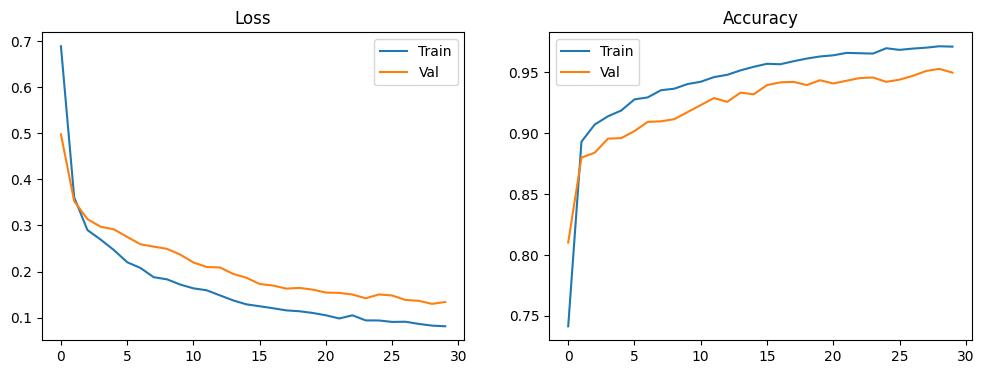

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()


## Evaluate on Test Set

In [11]:
model.evaluate([m1_test, m2_test, m3_test, m4_test], y_test)
y_pred_proba = model.predict([m1_test, m2_test, m3_test, m4_test], batch_size=32)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9484 - loss: 0.1650  
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
              precision    recall  f1-score   support

           0       0.68      0.95      0.79        60
           1       0.97      0.89      0.93       873
           2       0.95      0.98      0.97      1317

    accuracy                           0.95      2250
   macro avg       0.87      0.94      0.90      2250
weighted avg       0.95      0.95      0.95      2250



## Confusion Matrix

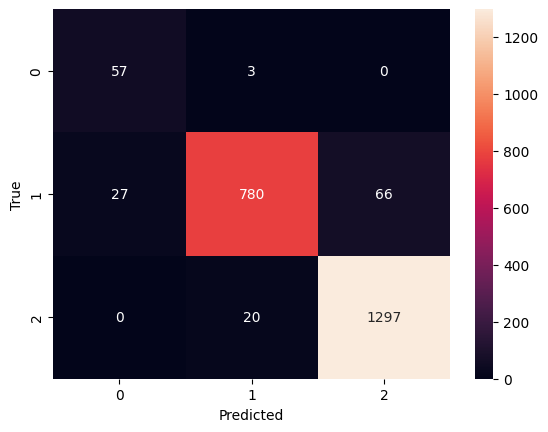

In [12]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Error Analysis
- Common Failure Pattern: Fusion inherits all above failure modes; low-confidence cases.
- Likely Cause: When 3+ modalities disagree, fusion averages toward wrong class.
- Potential Fix: Add confidence thresholding: abstain when max prob < 0.5.

In [13]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

label_names = ["Fake/Untrustworthy", "Suspicious", "Trusted"]

sample_errors = wrong_idx[:5]
for i in sample_errors:
    print(f"\n--- Sample {i} ---")
    print(f"True label: {label_names[y_true[i]]}")
    print(f"Predicted label: {label_names[y_pred[i]]}")
    print(f"Confidence: {y_pred_proba[i][y_pred[i]]*100:.1f}%")

for i, cls in enumerate(label_names[:min(len(label_names), cm.shape[0])]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    if total > 0:
        print(f"{cls}: FP={fp}, FN={fn}, FNR={fn/total*100:.1f}% (missed), FPR={fp/max(1, (cm.sum()-total))*100:.1f}% (false alarms)")



Total misclassified: 116 / 2250 (5.2%)

--- Sample 15 ---
True label: Suspicious
Predicted label: Trusted
Confidence: 59.2%

--- Sample 40 ---
True label: Suspicious
Predicted label: Trusted
Confidence: 53.9%

--- Sample 53 ---
True label: Suspicious
Predicted label: Trusted
Confidence: 79.9%

--- Sample 64 ---
True label: Fake/Untrustworthy
Predicted label: Suspicious
Confidence: 51.3%

--- Sample 87 ---
True label: Suspicious
Predicted label: Fake/Untrustworthy
Confidence: 89.1%
Fake/Untrustworthy: FP=27, FN=3, FNR=5.0% (missed), FPR=1.2% (false alarms)
Suspicious: FP=23, FN=93, FNR=10.7% (missed), FPR=1.7% (false alarms)
Trusted: FP=66, FN=20, FNR=1.5% (missed), FPR=7.1% (false alarms)


## Save Extractor

In [14]:
model.save(os.path.join(SAVED_MODELS_DIR, 'M5_final.keras'))
